<a href="https://colab.research.google.com/github/kadedamola40-svg/Learning-Journal/blob/main/Hackathon1_Adedamola.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pathlib import Path
import logging, sys, re
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

RAW_DIR     = Path('data/raw')
PROC_DIR    = Path('data/processed')
LOG_DIR     = Path('logs')
REPORTS_DIR = Path('reports')
FIGURES_DIR = REPORTS_DIR / 'figures'

CSV_FILE      = RAW_DIR / 'orders.csv'
LOG_FILE_PATH = RAW_DIR / 'access.txt'
LOG_OUT       = LOG_DIR / 'hackathon.log'

for p in [RAW_DIR, PROC_DIR, LOG_DIR, REPORTS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)


In [ ]:
logger = logging.getLogger('hackathon')
logger.setLevel(logging.INFO)
logger.handlers.clear()

fmt = logging.Formatter('%(asctime)s | %(levelname)s | %(message)s')

fh = logging.FileHandler(LOG_OUT, encoding='utf-8')
fh.setFormatter(fmt); logger.addHandler(fh)

ch = logging.StreamHandler(sys.stdout)
ch.setFormatter(fmt); logger.addHandler(ch)

logger.info('Setup complete')


2026-05-19 09:34:13,429 | INFO | Setup complete


INFO:hackathon:Setup complete


In [ ]:
peek = pd.read_csv(CSV_FILE, nrows=5)
print(peek)
print(peek.columns.tolist())




   order_id  user_id  product_id  quantity             order_ts  \
0     61763      456    80000347         3  2025-08-09 09:57:51   
1     81295     2200    80000041         1  2026-01-07 19:55:11   
2     80453     2665    80000323         3  2026-04-20 18:07:38   
3     71844     1755    80000227         3  2025-10-10 06:43:41   
4     65678     3510    80000097         2  2025-10-30 11:53:42   

             user_name         product_name  unit_price  
0      Suzanne Spencer     DodgerBlue Rerum       32.09  
1        Samantha Holt       DimGray Maxime       31.52  
2  Ashley Gill-Goodwin  PowderBlue Sapiente       34.01  
3     Leanne Middleton  PowderBlue Incidunt       47.52  
4  Mrs Lorraine Arnold            Silver Id       13.03  
['order_id', 'user_id', 'product_id', 'quantity', 'order_ts', 'user_name', 'product_name', 'unit_price']


In [ ]:
with open(LOG_FILE_PATH, 'r', encoding='utf-8', errors='ignore') as f: n_lines = sum(1 for _ in f)
print(f'access.log has {n_lines:,} lines')


access.log has 100,695 lines


In [ ]:
def load_csv(path: Path) -> pd.DataFrame:
    """Read a CSV and log shape + nulls."""
    logger.info(f'Loading CSV: {path}')
    df = pd.read_csv(path)
    logger.info(f'  rows: {df.shape[0]:,}, cols: {df.shape[1]}')
    null_pct = (df.isna().mean() * 100).round(2)
    logger.info(f'  null %: {null_pct.to_dict()}')
    return df

df_csv = load_csv(CSV_FILE)
df_csv.head()


2026-05-19 09:34:23,178 | INFO | Loading CSV: data/raw/orders.csv


INFO:hackathon:Loading CSV: data/raw/orders.csv


2026-05-19 09:34:23,233 | INFO |   rows: 50,750, cols: 8


INFO:hackathon:  rows: 50,750, cols: 8


2026-05-19 09:34:23,244 | INFO |   null %: {'order_id': 0.0, 'user_id': 0.0, 'product_id': 0.0, 'quantity': 0.0, 'order_ts': 0.0, 'user_name': 2.0, 'product_name': 1.49, 'unit_price': 1.0}


INFO:hackathon:  null %: {'order_id': 0.0, 'user_id': 0.0, 'product_id': 0.0, 'quantity': 0.0, 'order_ts': 0.0, 'user_name': 2.0, 'product_name': 1.49, 'unit_price': 1.0}


,order_id,user_id,product_id,quantity,order_ts,user_name,product_name,unit_price
0,61763,456,80000347,3,2025-08-09 09:57:51,Suzanne Spencer,DodgerBlue Rerum,32.09
1,81295,2200,80000041,1,2026-01-07 19:55:11,Samantha Holt,DimGray Maxime,31.52
2,80453,2665,80000323,3,2026-04-20 18:07:38,Ashley Gill-Goodwin,PowderBlue Sapiente,34.01
3,71844,1755,80000227,3,2025-10-10 06:43:41,Leanne Middleton,PowderBlue Incidunt,47.52
4,65678,3510,80000097,2,2025-10-30 11:53:42,Mrs Lorraine Arnold,Silver Id,13.03


In [ ]:
def parse_log_line(line):
    try:
        ip = line.split(' ')[0]

        ts = line[ line.index('[')+1 : line.index(']') ]

        quoted = line.split('"')
        method, path, *_ = quoted[1].split(' ') # "GET /home HTTP/1.1"
        after  = quoted[2].strip().split() # "200 1234 ..."
        status = int(after[0])
        size   = int(after[1]) if after[1].isdigit() else None

        return {'ip': ip, 'timestamp': ts,
                'method': method, 'path': path,
                'status': status, 'size': size}
    except (ValueError, IndexError):
        return None



In [ ]:
def load_log(path: Path) -> pd.DataFrame:
    logger.info(f'Loading log: {path}')
    rows, skipped = [], 0
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            if not line.strip(): continue
            result = parse_log_line(line)
            if result:
                # TODO-2a: append result to rows
                rows.append(result)
            else:
                # TODO-2b: increment the skipped counter
                skipped += 1

                 # TODO-2c: fill in the two counts in the log message below
    logger.info(f'parsed: {len(rows):,}, skipped: {skipped:,}')
    return pd.DataFrame(rows)

df_log = load_log(LOG_FILE_PATH)
df_log.head()


2026-05-19 11:50:15,619 | INFO | Loading log: data/raw/access.txt


INFO:hackathon:Loading log: data/raw/access.txt


2026-05-19 11:50:15,822 | INFO | parsed: 99,502, skipped: 1,174


INFO:hackathon:parsed: 99,502, skipped: 1,174


,ip,timestamp,method,path,status,size
0,184.78.115.41,06/Jan/2026:06:39:39 +0000,GET,/product/80000075,200,1052
1,173.221.186.57,19/Sep/2025:06:10:29 +0000,GET,/product/80000326,500,915
2,16.85.123.109,02/Dec/2025:15:38:32 +0000,GET,/product/80000151,200,548
3,164.202.110.186,30/Oct/2025:14:44:28 +0000,GET,/product/80000057,404,549
4,37.148.160.245,13/Jul/2025:08:09:31 +0000,GET,/product/80000231,200,608


In [ ]:
logger.info(f'before clean: {len(df_csv):,} rows')
n_dups = df_csv.duplicated(subset=['order_id']).sum()
logger.info(f'  duplicate order_ids: {n_dups:,}')
print(df_csv.isna().sum())

df_clean = df_csv.copy()
before = len(df_clean)

2026-05-19 12:47:01,720 | INFO | before clean: 50,750 rows


INFO:hackathon:before clean: 50,750 rows


2026-05-19 12:47:01,724 | INFO |   duplicate order_ids: 750


INFO:hackathon:  duplicate order_ids: 750


order_id           0
user_id            0
product_id         0
quantity           0
order_ts           0
user_name       1013
product_name     758
unit_price       505
dtype: int64


In [ ]:
# TODO-3a: What column identifies a unique order? Ans-> order_id

# One order should appear exactly once. Which column says so? Ans-> order_id because it's a unique identifier for each other
df_clean = df_clean.drop_duplicates(subset=['order_id'], keep='first')

logger.info(f'removed {before - len(df_clean):,} duplicate rows')

2026-05-19 12:47:29,572 | INFO | removed 750 duplicate rows


INFO:hackathon:removed 750 duplicate rows


In [ ]:
# TODO-3b (i): what value should replace missing user_name? Unknown (think: do we still want the order? Yes as long as the order is still valid )
df_clean['user_name'] = df_clean['user_name'].fillna('unknown')
# Justification: We should keep the order even if the username is missing. As the order is still valid, we replace missing value with Unknown rather than dropping the row.

# Rule 2 — product_name
# TODO-3b (ii): what value should replace missing product_name? unknown should replace missing product_name (we have product_id too)
df_clean['product_name'] = df_clean['product_name'].fillna('unknown')
# Justification: We already have product_id, which is a unique identifier for the product. therefor name is not essential, so we can safely fill missing values with a placeholder rather losing the record.

# Rule 3 — unit_price
# TODO-3b (iii): we can't fill unit_price (we'd be inventing numbers). What to do? Should be removed
before = len(df_clean)

df_clean = df_clean.dropna(subset=['unit_price'])
logger.info(f'dropped {before - len(df_clean):,} rows missing price')

# Justification: We can't fill the unit_price because that would mean inventing financial data, which is incorrect and misleading.
# I belive price is important for any analysis that may involve revenue or totals, anyrow without i should be removed.




2026-05-19 11:54:31,746 | INFO | dropped 0 rows missing price


INFO:hackathon:dropped 0 rows missing price


In [ ]:
def assert_unique(df, cols, name):
    if df.duplicated(subset=cols).any():
        raise AssertionError(f'{name}: duplicates on {cols}')
    logger.info(f'{name}: PK unique on {cols}')
def assert_no_orphans(child, parent, fk, pk, child_name, parent_name):
    missing = ~child[fk].isin(parent[pk])
    if missing.any():
        raise AssertionError(f'{child_name}: {missing.sum()} orphans')
    logger.info(f'{child_name}.{fk} → {parent_name}.{pk}: no orphans')

# TODO-4a - which columns describe a USER? User_id and user_name
# A user has an ID and a name. Anything else?
users = (df_clean[['user_id' , 'user_name' ]]
        .drop_duplicates(subset=['user_id']).reset_index(drop=True))

# TODO-4b - which columns describe a PRODUCT? product_id, product_name and maybe unit price
# A product has an ID, a name, and a price.

products = (df_clean[[ 'product_id','product_name', 'unit_price' ]]
           .drop_duplicates(subset=['product_id'], keep='first')
           .reset_index(drop=True))

# TODO-4c - which columns describe an ORDER (the header, not the items)? order_id , user_id and order_ts
# An order has an ID, a customer (FK to users), and a timestamp.
# It does NOT have product or quantity — those belong to order_items.

orders = (df_clean[[ 'order_id' , 'user_id' , 'order_ts' ]]
         .drop_duplicates().reset_index(drop=True))

# TODO-4d - which columns describe ORDER ITEMS?
# An order_item links an order to a product, with quantity and price.
# We also add a surrogate key (order_item_id) so every row is uniquely identifiable.

order_items = df_clean[[ 'order_id' , 'product_id' , 'quantity' , 'unit_price' ]].copy()
order_items.insert(0, 'order_item_id', range(1, len(order_items)+1))


# TODO-4e - fill in the primary key column(s) for each table
# Hint: a PK is the smallest column (or set of columns) that uniquely
# identifies a row. users → user_id alone. order_items needs TWO columns.

assert_unique(users,       cols=['user_id'],       name='users')
assert_unique(products,    cols=['product_id'],       name='products')
assert_unique(orders,      cols=['order_id'],       name='orders')
assert_unique(order_items, cols=['order_id', 'product_id'],       name='order_items')

# FK checks (these are given — they should pass if your splits above were right):

assert_no_orphans(orders,      users,    'user_id',    'user_id',
                  'orders', 'users')
assert_no_orphans(order_items, orders,   'order_id',   'order_id',
                  'order_items', 'orders')
assert_no_orphans(order_items, products, 'product_id', 'product_id',
                  'order_items', 'products')

def save_table(df, name):
    out = PROC_DIR / f'{name}.csv'
    df.to_csv(out, index=False)
    logger.info(f'saved {name}: {len(df):,} rows → {out}')

tables = {'users': users, 'products': products,
          'orders': orders, 'order_items': order_items}

for name, t in tables.items():
    save_table(t, name)


2026-05-19 12:45:56,479 | INFO | users: PK unique on ['user_id']


INFO:hackathon:users: PK unique on ['user_id']


2026-05-19 12:45:56,482 | INFO | products: PK unique on ['product_id']


INFO:hackathon:products: PK unique on ['product_id']


2026-05-19 12:45:56,486 | INFO | orders: PK unique on ['order_id']


...

INFO:hackathon:saved products: 350 rows → data/processed/products.csv


2026-05-19 12:45:56,552 | INFO | saved orders: 49,500 rows → data/processed/orders.csv


INFO:hackathon:saved orders: 49,500 rows → data/processed/orders.csv


2026-05-19 12:45:56,616 | INFO | saved order_items: 49,500 rows → data/processed/order_items.csv


INFO:hackathon:saved order_items: 49,500 rows → data/processed/order_items.csv


In [ ]:
print(users.shape, products.shape, orders.shape, order_items.shape)

(4999, 2) (350, 3) (49500, 3) (49500, 5)


<Axes: ylabel='Frequency'>

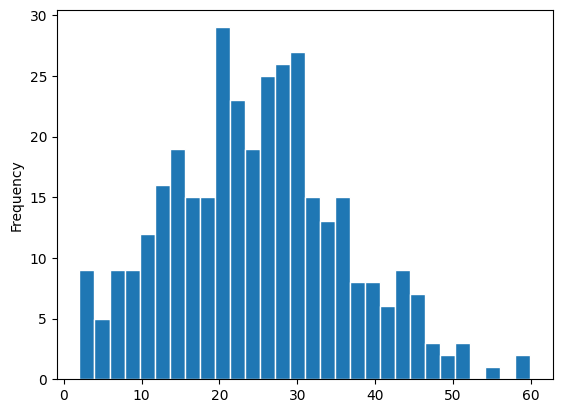

In [ ]:
# 5.1 A reusable save_fig helper

def save_fig(name):
    out = FIGURES_DIR / f'{name}.png'
    plt.savefig(out, bbox_inches='tight', dpi=150)
    plt.close()
    logger.info(f'figure saved → {out}')



# TODO-5a / 5b - histogram of unit prices

# TODO-5a: which numeric column shows the price distribution? Unit_price

products['unit_price'].plot(kind='hist', bins=30, edgecolor='white')

Text(0.5, 1.0, 'Distribution of product unit prices')

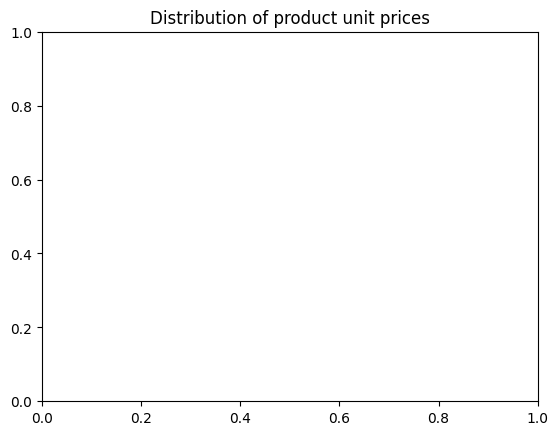

In [ ]:
# TODO-5b: write a meaningful title (e.g. 'Distribution of product unit prices')
plt.title('Distribution of product unit prices')

Text(0, 0.5, 'count')

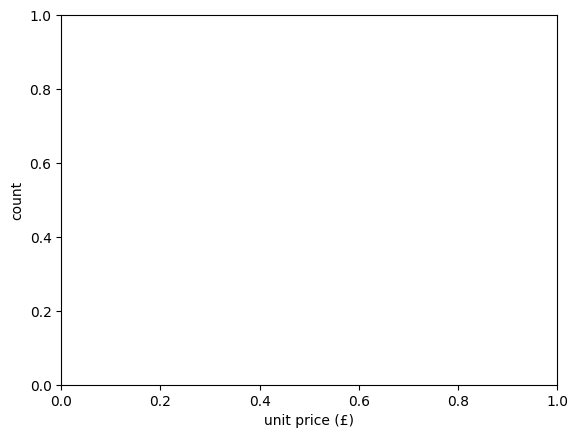

In [ ]:
plt.xlabel('unit price (£)'); plt.ylabel('count')

In [ ]:
save_fig('hist_unit_price')

2026-05-19 11:46:30,344 | INFO | figure saved → reports/figures/hist_unit_price.png


INFO:hackathon:figure saved → reports/figures/hist_unit_price.png


Text(0.5, 1.0, 'Distribution of product unit prices')

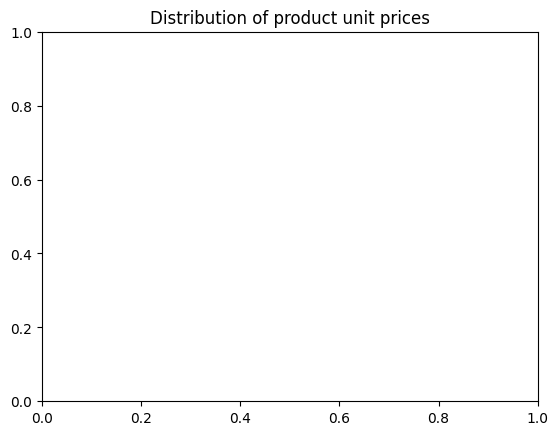

In [ ]:
# TODO-5b: write a meaningful title (e.g. 'Distribution of product unit prices')
plt.title('Distribution of product unit prices')

Text(0, 0.5, 'count')

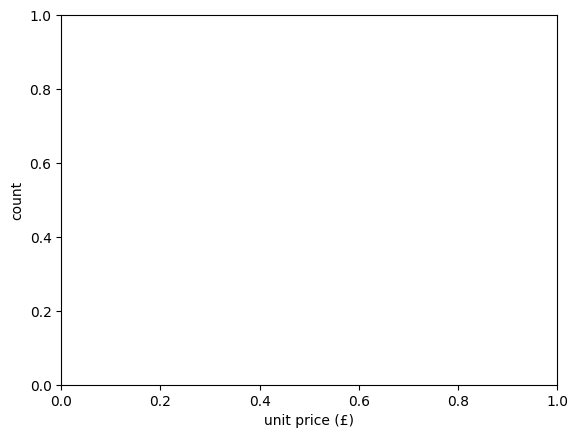

In [ ]:
plt.xlabel('unit price (£)'); plt.ylabel('count')

In [ ]:
save_fig('hist_unit_price')

2026-05-19 12:07:14,450 | INFO | figure saved → reports/figures/hist_unit_price.png


INFO:hackathon:figure saved → reports/figures/hist_unit_price.png


<Axes: xlabel='product_id'>

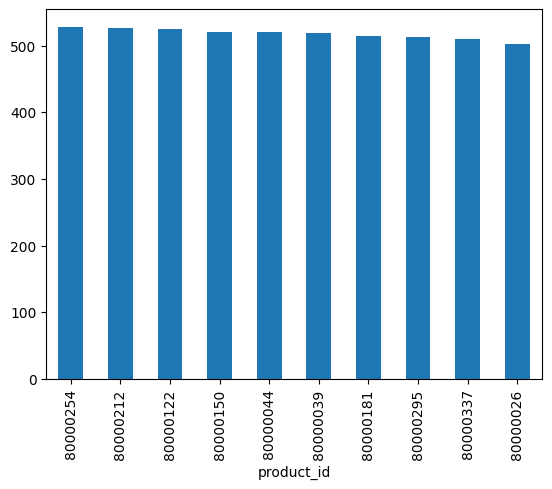

In [ ]:
# TODO-5c / 5d - top 10 products by units sold
# TODO-5c: which columns do you group by, and which do you sum? Ans -> product_id and quantity
# (think: total quantity per product)
top = (order_items
       .groupby('product_id')['quantity']
       .sum()
       .sort_values(ascending=False)
       .head(10))
top.plot(kind='bar')

Text(0.5, 1.0, 'Top 10 products by units sold')

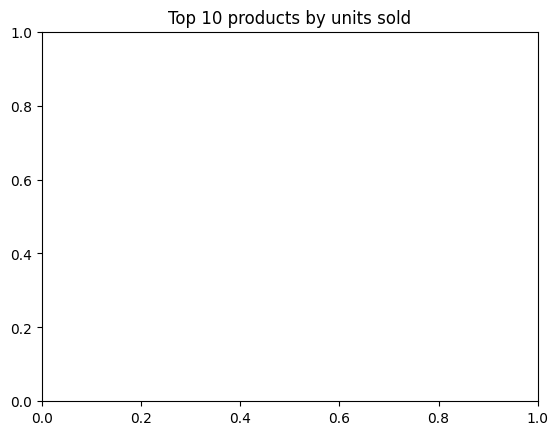

In [ ]:

# TODO-5d: meaningful title
plt.title('Top 10 products by units sold')


(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

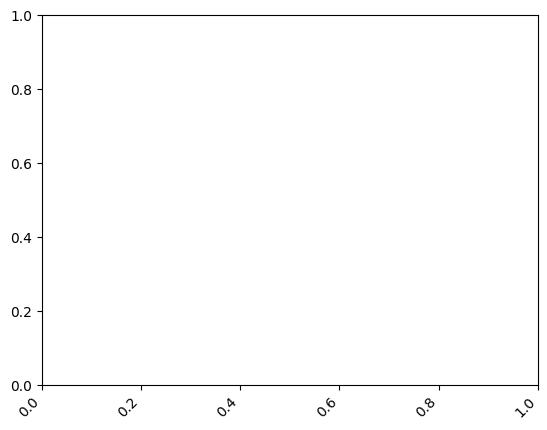

In [ ]:
plt.xticks(rotation=45, ha='right')

In [ ]:
save_fig('bar_top_products')

2026-05-19 11:42:31,647 | INFO | figure saved → reports/figures/bar_top_products.png


INFO:hackathon:figure saved → reports/figures/bar_top_products.png


<Axes: xlabel='order_ts'>

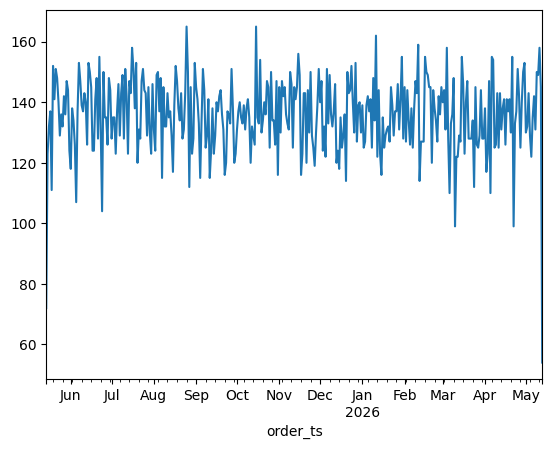

In [ ]:
 # TODO-5e / 5f - orders per day
o = orders.copy()

# TODO-5e: which column holds the order timestamp? Ans -> order_ts
o['order_ts'] = pd.to_datetime(o['order_ts'], errors='coerce')
daily = o.groupby(pd.Grouper(key='order_ts', freq='D')).size()
daily.plot(kind='line')

Text(0.5, 1.0, 'Orders per Day')

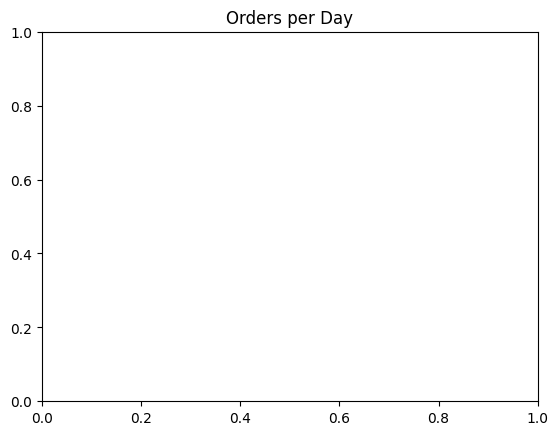

In [ ]:
# TODO-5f: meaningful title
plt.title('Orders per Day')

Text(0, 0.5, 'orders')

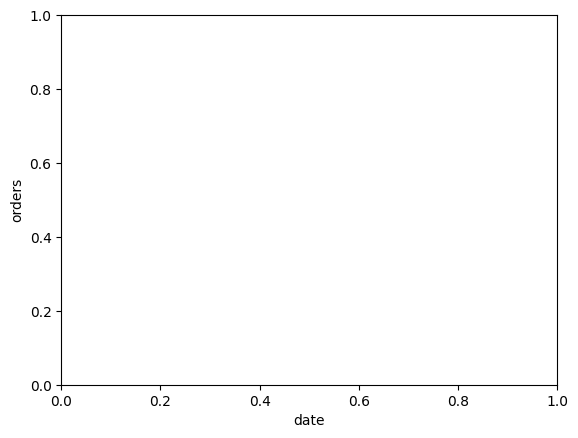

In [ ]:
plt.xlabel('date'); plt.ylabel('orders')

In [ ]:
save_fig('line_orders_per_day')

2026-05-19 13:01:41,089 | INFO | figure saved → reports/figures/line_orders_per_day.png


INFO:hackathon:figure saved → reports/figures/line_orders_per_day.png


In [67]:
# TODO-5g - replace the three ___ lines with one-sentence insights

# Step 5.3 - Write your three insights

median_price = products['unit_price'].median()

top_id = top.index[0]; top_units = int(top.iloc[0])

busy_day = daily.idxmax(); busy_n = int(daily.max())

summary = f'''# Comet Retail — Hackathon EDA Summary

1. The median product price is £{median_price:.2f}, indicating a typical price point across the catalogue. (use median_price)
2. Product {top_id} is the best-selling item with {top_units:,} units sold, making it the top performer by volume.  (use top_id and top_units)
3. The busiest day was {busy_day.date()} with {busy_n:,} orders, representing the peak in daily demand.  (use busy_day and busy_n)
'''
(REPORTS_DIR / 'EDA_summary.md').write_text(summary)

403

In [ ]:

def load_data(path):
    df = pd.read_csv(path)
    logger.info(f'loaded {len(df):,} rows from {path}')
    return df


def clean_orders(df: pd.DataFrame) -> pd.DataFrame:
    """Dedupe on order_id and apply null rules."""
    if df.empty:
        logger.warning('clean_orders: empty input')
        return df.copy()

    out = df.copy()


# Remove duplicates
    before = len(out)
    out = out.drop_duplicates(subset=['order_id'], keep='first')
    logger.info(f'clean: removed {before - len(out):,} dupes')


 # Fill missing text fields
    for col in ('user_name', 'product_name'):
        n = out[col].isna().sum()
        out[col] = out[col].fillna('unknown')
        if n:
            logger.info(f'clean: filled {n:,} {col}')


# Drop missing price
    before = len(out)
    out = out.dropna(subset=['unit_price'])
    logger.info(f'clean: dropped {before - len(out):,} no-price rows')

    return out



In [ ]:

def build_tables(df_clean):
    users = (df_clean[['user_id', 'user_name']]
             .drop_duplicates()
             .reset_index(drop=True))
    products = (df_clean[['product_id', 'product_name', 'unit_price']]
                .drop_duplicates(subset=['product_id'], keep='first')
                .reset_index(drop=True))

    orders = (df_clean[['order_id', 'user_id', 'order_ts']]
                  .drop_duplicates()
                  .reset_index(drop=True))


    order_items = df_clean[['order_id', 'product_id', 'quantity', 'unit_price']].copy()
    order_items.insert(0, 'order_item_id', range(1, len(order_items)+1))

    return users, products, orders, order_items


In [62]:

def save_table(df, name, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / f'{name}.csv'

    df.to_csv(path, index=False)
    logger.info(f'saved {name}: {len(df):,} rows → {path}')


In [61]:

def save_all_tables(tables, out_dir):
    for name, df in tables.items():
        save_table(df, name, out_dir)


In [60]:

def create_plots(products, order_items, orders):
    # Histogram
    products['unit_price'].plot(kind='hist', bins=30, edgecolor='white')
    plt.title('Distribution of product unit prices')
    plt.xlabel('unit price (£)')
    plt.ylabel('count')
    save_fig('hist_unit_price')
    plt.clf()


    # Top products
    top = (order_items
           .groupby('product_id')['quantity']
           .sum()
           .sort_values(ascending=False)
           .head(10))

    top.plot(kind='bar')
    plt.title('Top 10 products by units sold')
    plt.xticks(rotation=45, ha='right')
    save_fig('bar_top_products')
    plt.clf()


    # Orders per day
    o = orders.copy()
    o['order_ts'] = pd.to_datetime(o['order_ts'], errors='coerce')

    daily = o.groupby(pd.Grouper(key='order_ts', freq='D')).size()
    daily.plot(kind='line')

    plt.title('Number of orders per day')
    plt.xlabel('date')
    plt.ylabel('orders')
    save_fig('line_orders_per_day')
    plt.clf()

    return top, daily



In [59]:
def create_summary(products, top, daily, out_dir):
    median_price = products['unit_price'].median()
    top_id = top.index[0]
    top_units = int(top.iloc[0])
    busy_day = daily.idxmax()
    busy_n = int(daily.max())

    summary = f'''# Comet Retail — Hackathon EDA Summary

1. The median product price is £{median_price:.2f}, indicating a typical price point across the catalogue.
2. Product {top_id} is the best-selling item with {top_units:,} units sold.
3. The busiest day was {busy_day.date()} with {busy_n:,} orders.
'''

    out_path = out_dir / 'EDA_summary.md'
    out_path.write_text(summary)
    logger.info(f'saved summary → {out_path}')

In [65]:
def clean_orders(df: pd.DataFrame) -> pd.DataFrame:
    """Dedupe on order_id and apply our null rules."""
    if df.empty:
        logger.warning('clean_orders: empty input'); return df.copy()
    out = df.copy()
    before = len(out)
    out = out.drop_duplicates(subset=['order_id'], keep='first')
    logger.info(f'clean: removed {before - len(out):,} dupes')
    for col in ('user_name', 'product_name'):
        n = out[col].isna().sum()
        out[col] = out[col].fillna('unknown')
        if n: logger.info(f'clean: filled {n:,} {col}')
    before = len(out)
    out = out.dropna(subset=['unit_price'])
    logger.info(f'clean: dropped {before - len(out):,} no-price rows')
    return out


In [73]:
def run_pipeline():
    logger.info('Starting pipeline...')

    # 1. Load CSV
    df_csv = load_csv(CSV_FILE)

    # 2. Clean orders
    df_clean = clean_orders(df_csv)

    # 3. Build tables
    users, products, orders, order_items = build_tables(df_clean)
    tables = {'users': users, 'products': products,
              'orders': orders, 'order_items': order_items}
    save_all_tables(tables, PROC_DIR)

    # 4. Create plots
    top, daily = create_plots(products, order_items, orders)

    # 5. Create summary
    create_summary(products, top, daily, REPORTS_DIR)

    logger.info('Pipeline finished.')

run_pipeline()

2026-05-19 19:54:48,558 | INFO | Starting pipeline...


INFO:hackathon:Starting pipeline...


2026-05-19 19:54:48,562 | INFO | Loading CSV: data/raw/orders.csv


INFO:hackathon:Loading CSV: data/raw/orders.csv


2026-05-19 19:54:48,685 | INFO |   rows: 50,750, cols: 8


...

2026-05-19 19:54:49,953 | INFO | saved summary → reports/EDA_summary.md


INFO:hackathon:saved summary → reports/EDA_summary.md


2026-05-19 19:54:49,954 | INFO | Pipeline finished.


INFO:hackathon:Pipeline finished.


<Figure size 640x480 with 0 Axes>